<a href="https://colab.research.google.com/github/marianamq-a11y/Estatistica-mariana/blob/main/tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 13 -  Distribuição Normal, T de Student, Qui-quadrado e F de Fisher

Lais Zanquettim Stocco Teixeira - 14586772

Mariana Lopes Marques -14596593

Nayara Penati - 15677365

##Introdução

Na indústria alimentar e enológica, a garantia da qualidade exige realizar inferências populacionais rigorosas a partir de amostras de produção. Utilizando os dados da base Wine Quality, este estudo combina quatro distribuições fundamentais: a Normal e a $t$ de Student estimam os parâmetros centrais e os padrões médios de qualidade (como o pH e a acidez média), enquanto a Qui-Quadrado  e a $F$ de Fisher avaliam a estabilidade dos processos e comparam a variabilidade entre grupos (como o controlo da dispersão no envasamento e a comparação de acidez entre vinhos tintos e brancos). Esta abordagem estatística integrada permite antecipar não conformidades, otimizar tolerâncias e assegurar a padronização e segurança do produto final.

##Base de Dados
Utilizamos a base de dados de qualidade de vinho do "Repositório de Aprendizado de Máquina da UCI"(Wine Quality: https://archive.ics.uci.edu/dataset/186/wine+quality). Ela nos trás informações com medições físico-químicas de vinhos tintos e branco, osnde conseguimos avaliar as variáveis e probabilidades com aplicação de "distribuição normal, T de studant, qui-quadrado e F de fisher".

##Fórmula da Densidade da Distribuição Normal
A Função Densidade de Probabilidade de uma variável aleatória contínua $X$ com Distribuição Normal é expressa por:

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2\right)$$
Onde:
- x: Valor assumido pela variável aleatória contínua;
- μ:
  é a média da distribuição;
- σ: é o desvio padrão da distribuição, note que: √2π=σ;
- σ^2:
 é a varância da distribuição;
 - $\pi$: Constante matemática;
-  $e$: Base do logaritmo natural.

##Aplicação Prática no Controle de Qualidade de Alimentos e Bebidas
Na indústria alimentícia e na enologia, a Distribuição Normal é uma ferramenta indispensável para monitorar a padronização e a segurança dos produtos. Ao analisar características físico-químicas contínuas presentes no banco de dados de vinhos (como o pH, a acidez volátil ou o teor alcoólico), os parâmetros populacionais ganham interpretações práticas diretas:
- Média ($\mu$): O Padrão do Produto: Representa o valor central de referência ou a especificação ideal formulada para o produto. Em um lote de vinho, por exemplo, a média do pH determina o ponto de equilíbrio de acidez esperado para garantir o perfil sensorial e a conservação microbiológica adequados.
- Desvio-padrão ($\sigma$): A Métrica de Uniformidade e Estabilidade: Indicação direta da consistência do processo de fabricação e envasamento.

- $\sigma$ baixo: Reflete alta precisão operacional e padronização rigorosa, sinalizando que a grande maioria das garrafas apresenta valores de pH muito próximos ao ideal;
- $\sigma$ alto: Indica oscilações na matéria-prima, falhas no controle de fermentação ou desregulagem no envasamento, resultando em lotes heterogêneos com riscos de alteração no sabor ou na vida de prateleira.

##Condições de aplicação e limitação
Condições de Aplicação:

- Variável Contínua: O parâmetro medido deve ser uma variável quantitativa contínua.
- Simetria em Torno do Centro: A curva apresenta formato em sino, onde média, mediana e moda coincidem no centro da distribuição.
- Soma de Múltiplos Fatores: É adequada quando a variação decorre do efeito acumulado de diversos fatores independentes (Teorema do Limite Central).

Limitação:
- Amplitude Teórica Infinita: A curva teórica varia de $-\infty$ a $+\infty$, porém propriedades químicas de alimentos (como teor alcoólico ou pH) não assumem valores negativos;
- Sensibilidade a Outliers: Dados discrepantes decorrentes de erros de medição distorcem os estimadores de $\mu$ e $\sigma$;
- Assimetria na Prática: Certos atributos alimentares podem apresentar assimetria natural à direita ou à esquerda.


##Gráficos Variando Média e Desvio-Padrão
Comparação entre a média (μ) e o desvio-padrão (σ).

*Alterar μ move o centro da curva para a esquerda ou para a direita (mudança de posição).

*Alterar σ comprime ou alarga a curva ao redor do centro (mudança de precisão).  

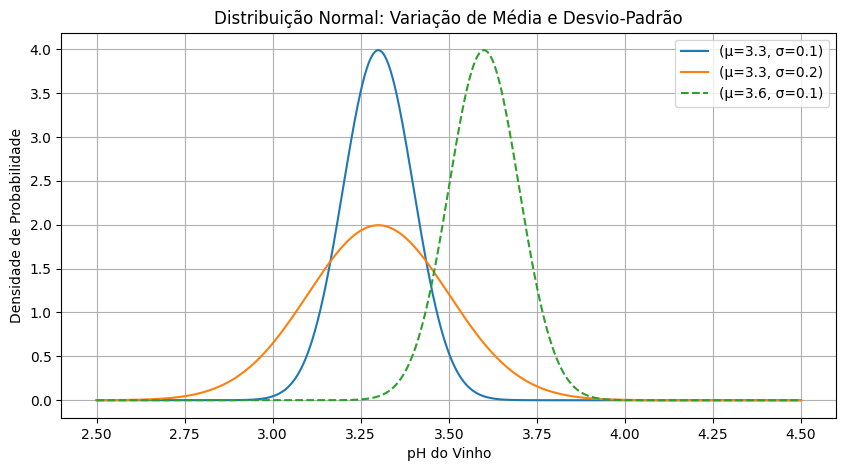

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(2.5, 4.5, 1000)

plt.figure(figsize=(10, 5))

# Variação do desvio-padrão (mesma média)
plt.plot(x, norm.pdf(x, loc=3.3, scale=0.1), label=r'(μ=3.3, σ=0.1)')
plt.plot(x, norm.pdf(x, loc=3.3, scale=0.2), label=r'(μ=3.3, σ=0.2)')

# Variação da média (mesmo desvio-padrão)
plt.plot(x, norm.pdf(x, loc=3.6, scale=0.1), label=r'(μ=3.6, σ=0.1)', linestyle='--')

plt.title('Distribuição Normal: Variação de Média e Desvio-Padrão')
plt.xlabel('pH do Vinho')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True)
plt.show()

## Cálculos de Probabilidade e Percentis (Distribuição Normal)

Utilizando os parâmetros definidos anteriormente para o pH do vinho ($\mu = 3.3$ e $\sigma = 0.1$), vamos realizar as seguintes análises probabilísticas:

1. **Probabilidade Acumulada**: $P(X \le 3.2)$
2. **Probabilidade entre dois valores**: $P(3.2 \le X \le 3.5)$
3. **Probabilidade acima de um valor**: $P(X > 3.4)$
4. **Percentil**: Encontrar o valor de pH que deixa 95% dos dados abaixo dele (Percentil 95).

In [ ]:
import numpy as np
from scipy.stats import norm

# Definição dos parâmetros da distribuição
mu = 3.3
sigma = 0.1

# 1. Probabilidade Acumulada: P(X <= 3.2)
prob_acumulada = norm.cdf(3.2, loc=mu, scale=sigma)
print(f"1. Probabilidade Acumulada P(X <= 3.2): {prob_acumulada:.4f} ({prob_acumulada*100:.2f}%)")

# 2. Probabilidade entre dois valores: P(3.2 <= X <= 3.5)
prob_entre = norm.cdf(3.5, loc=mu, scale=sigma) - norm.cdf(3.2, loc=mu, scale=sigma)
print(f"2. Probabilidade entre 3.2 e 3.5 P(3.2 <= X <= 3.5): {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# 3. Probabilidade acima de um valor: P(X > 3.4)
# P(X > 3.4) = 1 - P(X <= 3.4) ou usando a Survival Function (sf)
prob_acima = norm.sf(3.4, loc=mu, scale=sigma)
print(f"3. Probabilidade acima de 3.4 P(X > 3.4): {prob_acima:.4f} ({prob_acima*100:.2f}%)")

# 4. Calcular o Percentil: Exemplo para o Percentil 95 (0.95)
percentil_95 = norm.ppf(0.95, loc=mu, scale=sigma)
print(f"4. Percentil 95 (valor de pH onde 95% das amostras estão abaixo): {percentil_95:.4f}")

1. Probabilidade Acumulada P(X <= 3.2): 0.1587 (15.87%)
2. Probabilidade entre 3.2 e 3.5 P(3.2 <= X <= 3.5): 0.8186 (81.86%)
3. Probabilidade acima de 3.4 P(X > 3.4): 0.1587 (15.87%)
4. Percentil 95 (valor de pH onde 95% das amostras estão abaixo): 3.4645


##Gráficos para representar as áreas sombreadas a partir da probabilidade
Os quatro gráficos gerados no Tópico mostram visualmente como a área sob a curva da Distribuição Normal corresponde ao cálculo direto de probabilidades e percentis no contexto do pH do vinho:

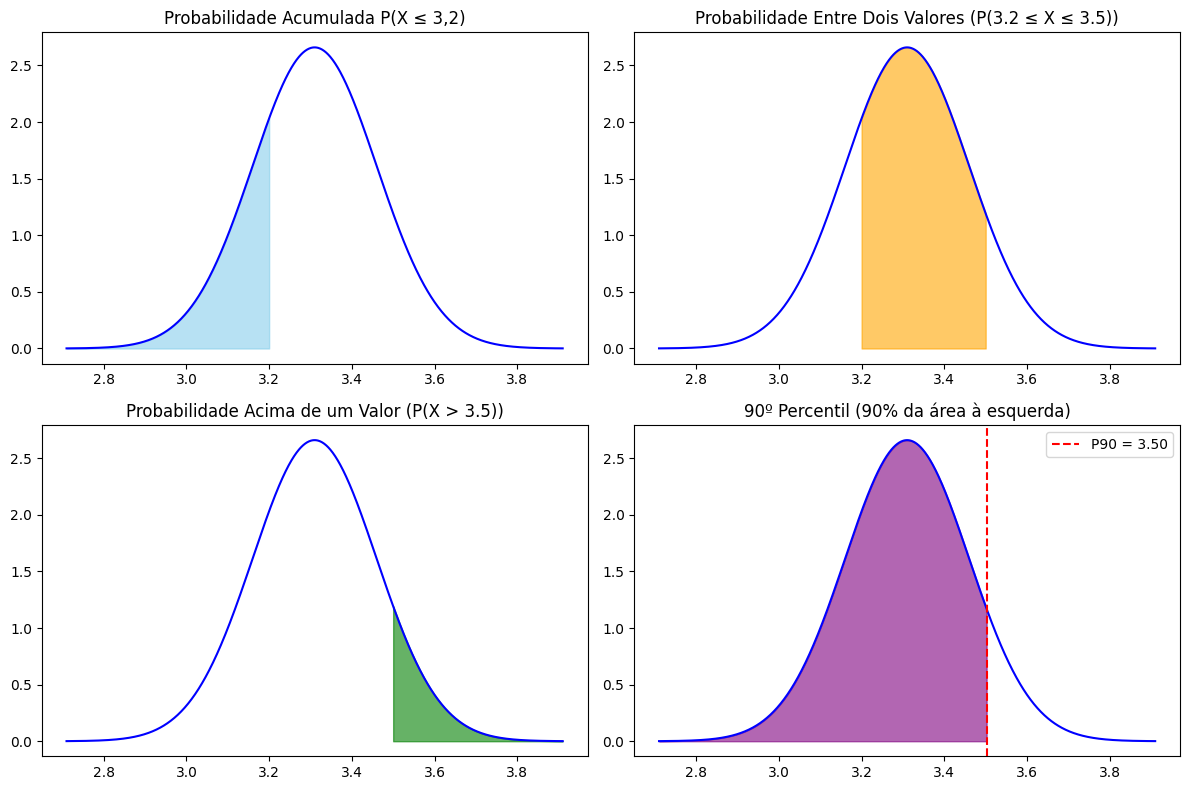

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parâmetros baseados na distribuição de pH do vinho
mu, sigma = 3.31, 0.15
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, loc=mu, scale=sigma)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Probabilidade Acumulada P(X <= 3.2)
axes[0, 0].plot(x, y, 'b')
x_fill1 = np.linspace(mu - 4*sigma, 3.2, 500)
axes[0, 0].fill_between(x_fill1, norm.pdf(x_fill1, mu, sigma), color='skyblue', alpha=0.6)
axes[0, 0].set_title(r'Probabilidade Acumulada P(X ≤ 3,2)')

# 2. Probabilidade Entre dois valores P(3.2 <= X <= 3.5)
axes[0, 1].plot(x, y, 'b')
x_fill2 = np.linspace(3.2, 3.5, 500)
axes[0, 1].fill_between(x_fill2, norm.pdf(x_fill2, mu, sigma), color='orange', alpha=0.6)
axes[0, 1].set_title(r'Probabilidade Entre Dois Valores (P(3.2 ≤ X ≤ 3.5))')

# 3. Probabilidade Acima de um valor P(X > 3.5)
axes[1, 0].plot(x, y, 'b')
x_fill3 = np.linspace(3.5, mu + 4*sigma, 500)
axes[1, 0].fill_between(x_fill3, norm.pdf(x_fill3, mu, sigma), color='green', alpha=0.6)
axes[1, 0].set_title(r'Probabilidade Acima de um Valor (P(X > 3.5))')

# 4. Percentil 90
p90 = norm.ppf(0.90, loc=mu, scale=sigma)
axes[1, 1].plot(x, y, 'b')
x_fill4 = np.linspace(mu - 4*sigma, p90, 500)
axes[1, 1].fill_between(x_fill4, norm.pdf(x_fill4, mu, sigma), color='purple', alpha=0.6)
axes[1, 1].axvline(p90, color='red', linestyle='--', label=f'P90 = {p90:.2f}')
axes[1, 1].set_title('90º Percentil (90% da área à esquerda)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

###Onde:
- Gráfico 1 (azul): A probabilidade de encontrar um vinho com pH igual ou inferior a 3,2;
- Gráfico 2 (laranja): A probabilidade de selecionar uma garrafa cujo pH esteja compreendido no intervalo entre 3,2 e 3,5;
- Gráfico 3 (verde): A probabilidade de obter um vinho com pH superior a 3,5;
- Gráfico 4 (roxo): O ponto de corte (limiar) no qual 90% das garrafas de vinho apresentam um pH menor ou igual a esse valor, enquanto apenas 10% apresentam um pH superior.

##  Distribuição $t$ de Student

- Função Densidade de Probabilidade (PDF)

A função densidade de probabilidade da distribuição $t$ de Student é dada pela equação:$$f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu \pi} \,\, \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu + 1}{2}}, \quad -\infty < t < \infty$$Definição dos Símbolos:

$t$: Variável aleatória padronizada da estatística de teste.

$\nu$: Graus de liberdade ($\nu = n - 1$, onde $n$ é o tamanho da amostra).

$\Gamma(\cdot)$: Função Gama, definida por $\Gamma(x) = \int_{0}^{\infty} u^{x-1} e^{-u} du$.


Graus de Liberdade e Formato da Curva

- Os graus de liberdade representam o número de observações independentes na amostra menos o número de parâmetros estimados. No contexto da média amostral com desvio-padrão populacional ($\sigma$) desconhecido, perdemos $1$ grau de liberdade ao estimar a média populacional ($\mu$) pela média amostral ($\bar{X}$), resultando em $\nu = n - 1$.


- Efeito na Forma e Caudas da Curva: A distribuição $t$ é simétrica em torno de zero e possui formato em sino, similar à Normal Padrão.
Para valores pequenos de $\nu$, as caudas são mais pesadas (maior probabilidade de ocorrência de valores distantes de zero) e o pico é mais achatado, refletindo a incerteza adicional trazida pela estimação do desvio-padrão amostral ($S$).

À medida que $\nu$ aumenta ($\nu \to \infty$), a variabilidade na estimativa do desvio-padrão diminui e a curva $t$ de Student converge para a distribuição Normal Padrão $\mathcal{N}(0, 1)$.

##Relação com a Base de Alimentos

Uma medição individual de acidez fixa (fixed acidity, em $g/dm^3$) reflete apenas uma garrafa de vinho. No entanto, para verificar se um lote industrial atende às normas técnicas quando o desvio-padrão da população inteira é desconhecido, coletamos uma amostra de tamanho $n$, calculamos a média amostral $\bar{X}$ e o desvio-padrão amostral $S$. A estatística padronizada:$$t = \frac{\bar{X} - \mu_0}{S / \sqrt{n}}$$segue rigorosamente uma distribuição $t$ de Student com $\nu = n - 1$ graus de liberdade.

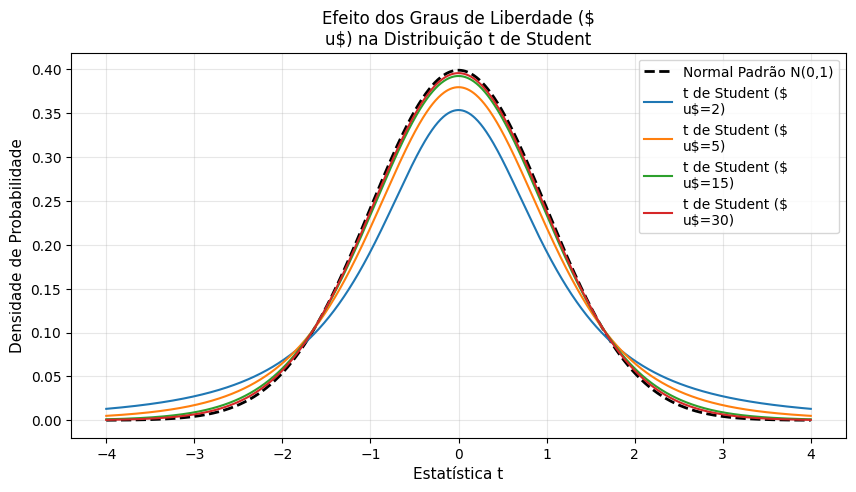

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Carregamento da base real de vinhos tintos (Wine Quality)
# Certifique-se de que o arquivo 'winequality-red.csv' esteja na mesma pasta do notebook
df_red = pd.read_csv('winequality-red.csv', sep=';')

# 1. Gráfico mostrando o efeito dos graus de liberdade (df) no formato e nas caudas da t de Student
x_t_sim = np.linspace(-4, 4, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x_t_sim, stats.norm.pdf(x_t_sim), 'k--', label='Normal Padrão N(0,1)', linewidth=2)

for df_val in [2, 5, 15, 30]:
    plt.plot(x_t_sim, stats.t.pdf(x_t_sim, df=df_val), label=f't de Student ($\nu$={df_val})')

plt.title('Efeito dos Graus de Liberdade ($\nu$) na Distribuição t de Student', fontsize=12)
plt.xlabel('Estatística t', fontsize=11)
plt.ylabel('Densidade de Probabilidade', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Problema Contextualizado e Cálculo de Probabilidades ($t$ de Student)

Contexto: O padrão de acidez fixa ideal especificado para um determinado tipo de vinho tinto é $\mu_0 = 8.31 \, g/dm^3$. Uma amostra aleatória de $n = 25$ garrafas foi retirada da base de dados. Logo, temos $\nu = 25 - 1 = 24$ graus de liberdade.

Desejamos calcular as seguintes probabilidades para a estatística $t$:

Probabilidade Acumulada: $P(T \le -1.5)$

Probabilidade Entre Dois Valores: $P(-1.0 \le T \le 1.5)

Probabilidade Acima de um Valor: $P(T > 2.0)$Percentil: O valor do percentil 95% ($t_{0.95}$)

In [18]:
# Definindo graus de liberdade para o problema
n_t = 25
df_t = n_t - 1  # 24 graus de liberdade

# 1. Probabilidade acumulada: P(T <= -1.5)
p_acum_t = stats.t.cdf(-1.5, df=df_t)

# 2. Probabilidade entre dois valores: P(-1.0 <= T <= 1.5)
p_entre_t = stats.t.cdf(1.5, df=df_t) - stats.t.cdf(-1.0, df=df_t)

# 3. Probabilidade acima de um valor: P(T > 2.0)
p_acima_t = stats.t.sf(2.0, df=df_t)  # sf = Survival Function (1 - cdf)

# 4. Percentil 95%
q95_t = stats.t.ppf(0.95, df=df_t)

print(f"--- RESULTADOS T DE STUDENT (df = {df_t}) ---")
print(f"1. Probabilidade acumulada P(T <= -1.5): {p_acum_t:.4f} ({p_acum_t*100:.2f}%)")
print(f"2. Probabilidade entre P(-1.0 <= T <= 1.5): {p_entre_t:.4f} ({p_entre_t*100:.2f}%)")
print(f"3. Probabilidade acima P(T > 2.0): {p_acima_t:.4f} ({p_acima_t*100:.2f}%)")
print(f"4. Percentil 95% (t_0.95): {q95_t:.4f}")

--- RESULTADOS T DE STUDENT (df = 24) ---
1. Probabilidade acumulada P(T <= -1.5): 0.0733 (7.33%)
2. Probabilidade entre P(-1.0 <= T <= 1.5): 0.7630 (76.30%)
3. Probabilidade acima P(T > 2.0): 0.0285 (2.85%)
4. Percentil 95% (t_0.95): 1.7109


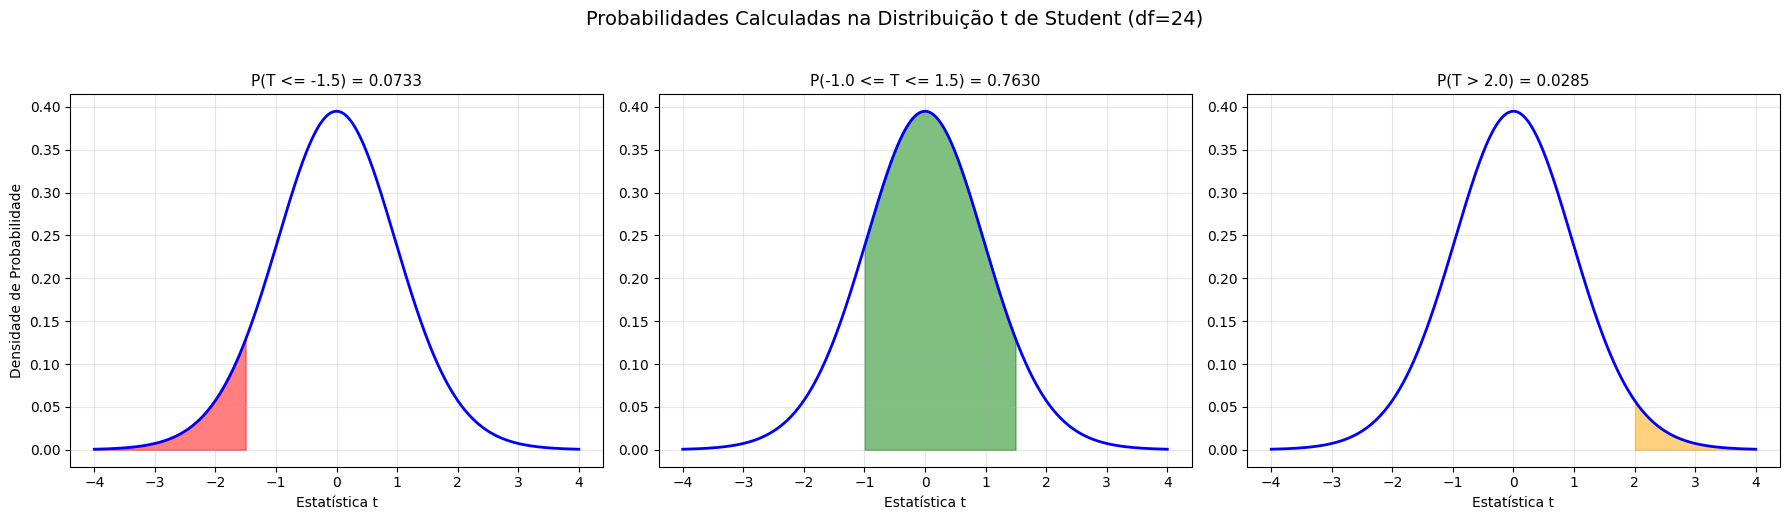

In [20]:
# Gráficos de Densidade com Áreas Sombreadas - t de Student
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_axis = np.linspace(-4, 4, 1000)
y_axis = stats.t.pdf(x_axis, df=df_t)

# Gráfico 1: P(T <= -1.5) - Probabilidade Acumulada
axes[0].plot(x_axis, y_axis, 'b-', lw=2)
axes[0].fill_between(x_axis, y_axis, where=(x_axis <= -1.5), color='red', alpha=0.5)
axes[0].set_title(f'P(T <= -1.5) = {p_acum_t:.4f}', fontsize=11)
axes[0].set_xlabel('Estatística t', fontsize=10)
axes[0].set_ylabel('Densidade de Probabilidade', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: P(-1.0 <= T <= 1.5) - Probabilidade Entre Dois Valores
axes[1].plot(x_axis, y_axis, 'b-', lw=2)
axes[1].fill_between(x_axis, y_axis, where=((x_axis >= -1.0) & (x_axis <= 1.5)), color='green', alpha=0.5)
axes[1].set_title(f'P(-1.0 <= T <= 1.5) = {p_entre_t:.4f}', fontsize=11)
axes[1].set_xlabel('Estatística t', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Gráfico 3: P(T > 2.0) - Probabilidade Acima de um Valor
axes[2].plot(x_axis, y_axis, 'b-', lw=2)
axes[2].fill_between(x_axis, y_axis, where=(x_axis > 2.0), color='orange', alpha=0.5)
axes[2].set_title(f'P(T > 2.0) = {p_acima_t:.4f}', fontsize=11)
axes[2].set_xlabel('Estatística t', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Probabilidades Calculadas na Distribuição t de Student (df=24)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## Distribuição Qui-Quadrado ($\chi^2$)

Função Densidade de Probabilidade (PDF)A função densidade de probabilidade da distribuição Qui-Quadrado é expressa por:$$f(x) = \frac{1}{2^{k/2} \, \Gamma(k/2)} \, x^{(k/2) - 1} \, e^{-x/2}, \quad \text{para } x > 0$$Definição dos Símbolos:

$x$: Variável aleatória contínua assumindo apenas valores não-negativos ($x \ge 0$).

$k$: Graus de liberdade ($k \in \mathbb{Z}^+$ e $k > 0$).

$\Gamma(\cdot)$: Função Gama.

$e$: Constante de Euler ($\approx 2.71828$).

Graus de Liberdade, Valores Possíveis e Assimetria

Valores Possíveis: A variável $X \sim \chi^2_k$ assume apenas valores reais positivos ou nulos ($x \ge 0$), pois é construída a partir da soma dos quadrados de $k$ variáveis normais padrão independentes ($X = \sum_{i=1}^k Z_i^2$).

Graus de Liberdade ($k$): Representam o número de variáveis normais independentes elevadas ao quadrado que compõem a soma.

Efeito no Formato e Assimetria:

Para valores baixos de $k$ (ex: $k = 1$ ou $k = 2$), a curva é fortemente assimétrica à direita (assimetria positiva) e o valor de densidade é concentrado próximo de zero.

Conforme $k$ aumenta, a média ($E[X] = k$) e a variância ($Var(X) = 2k$) aumentam, o pico da curva desloca-se para a direita e a distribuição torna-se progressivamente mais simétrica, aproximando-se de uma forma em sino (comportamento assintoticamente normal pelo Teorema Central do Limite).

Relação com a Variância Amostral de Alimentos

No controle de qualidade industrial, além de monitorar a média, é essencial controlar a variabilidade (variância) do processo. Por exemplo, a variação na quantidade de álcool (alcohol, em $\%$ vol.) entre garrafas de vinho precisa estar dentro de limites rigorosos.  

 Se a variável populacional for aproximadamente Normal com variância $\sigma^2$, a estatística calculada a partir da variância amostral $S^2$ de uma amostra de tamanho $n$:$$X^2 = \frac{(n-1) S^2}{\sigma^2}$$segue rigorosamente uma distribuição Qui-Quadrado com $k = n - 1$ graus de liberdade.



  
  



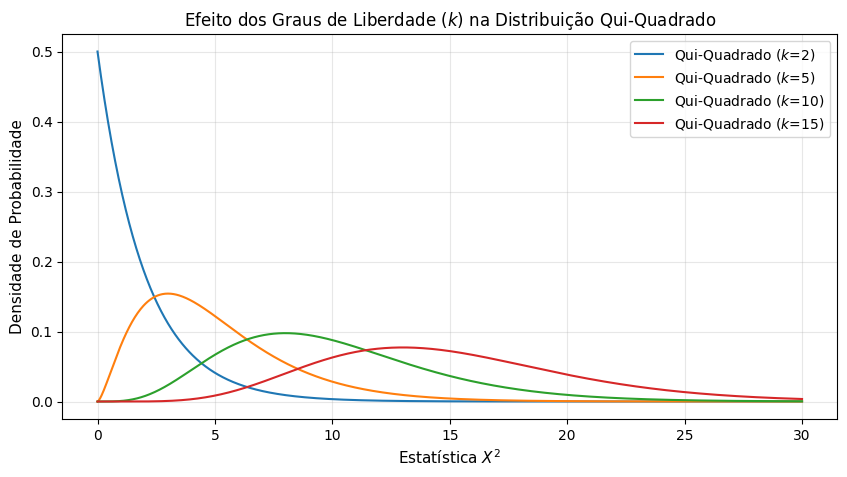

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Gráfico demonstrando o efeito do aumento dos graus de liberdade (k) na curva Qui-Quadrado
x_chi_sim = np.linspace(0, 30, 1000)

plt.figure(figsize=(10, 5))
for k_val in [2, 5, 10, 15]:
    plt.plot(x_chi_sim, stats.chi2.pdf(x_chi_sim, df=k_val), label=f'Qui-Quadrado ($k$={k_val})')

plt.title('Efeito dos Graus de Liberdade ($k$) na Distribuição Qui-Quadrado', fontsize=12)
plt.xlabel('Estatística $X^2$', fontsize=11)
plt.ylabel('Densidade de Probabilidade', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Problema Contextualizado e Cálculo de Probabilidades (χ
2
 )

Contexto: O setor de enologia monitora a estabilidade do teor alcoólico das garrafas de vinho tinto. Suponha que, para uma amostra aleatória de n=16 garrafas (k=16−1=15 graus de liberdade), sob a hipótese de estabilidade do processo (σ
2
 =σ
0
2
​
 ), calculamos a estatística Qui-Quadrado.   


Desejamos calcular as seguintes probabilidades:

Probabilidade Acumulada: $P(X^2 \le 8,0)$

Probabilidade Entre Dois Valores: $P(10,0 \le X^2 \le 22,0)$

Probabilidade Acima de um Valor: $P(X^2 > 25,0)$

Percentil: O valor do percentil 90% ($\chi^2_{0,90}$)



In [22]:
# Definindo graus de liberdade para o problema
n_chi = 16
k_df = n_chi - 1  # 15 graus de liberdade

# 1. Probabilidade acumulada: P(X^2 <= 8.0)
p_acum_chi = stats.chi2.cdf(8.0, df=k_df)

# 2. Probabilidade entre dois valores: P(10.0 <= X^2 <= 22.0)
p_entre_chi = stats.chi2.cdf(22.0, df=k_df) - stats.chi2.cdf(10.0, df=k_df)

# 3. Probabilidade acima de um valor: P(X^2 > 25.0)
p_acima_chi = stats.chi2.sf(25.0, df=k_df)  # sf = 1 - cdf

# 4. Percentil 90%
q90_chi = stats.chi2.ppf(0.90, df=k_df)

print(f"--- RESULTADOS QUI-QUADRADO (k = {k_df}) ---")
print(f"1. Probabilidade acumulada P(X^2 <= 8.0): {p_acum_chi:.4f} ({p_acum_chi*100:.2f}%)")
print(f"2. Probabilidade entre P(10.0 <= X^2 <= 22.0): {p_entre_chi:.4f} ({p_entre_chi*100:.2f}%)")
print(f"3. Probabilidade acima P(X^2 > 25.0): {p_acima_chi:.4f} ({p_acima_chi*100:.2f}%)")
print(f"4. Percentil 90% (X^2_0.90): {q90_chi:.4f}")

--- RESULTADOS QUI-QUADRADO (k = 15) ---
1. Probabilidade acumulada P(X^2 <= 8.0): 0.0762 (7.62%)
2. Probabilidade entre P(10.0 <= X^2 <= 22.0): 0.7119 (71.19%)
3. Probabilidade acima P(X^2 > 25.0): 0.0499 (4.99%)
4. Percentil 90% (X^2_0.90): 22.3071


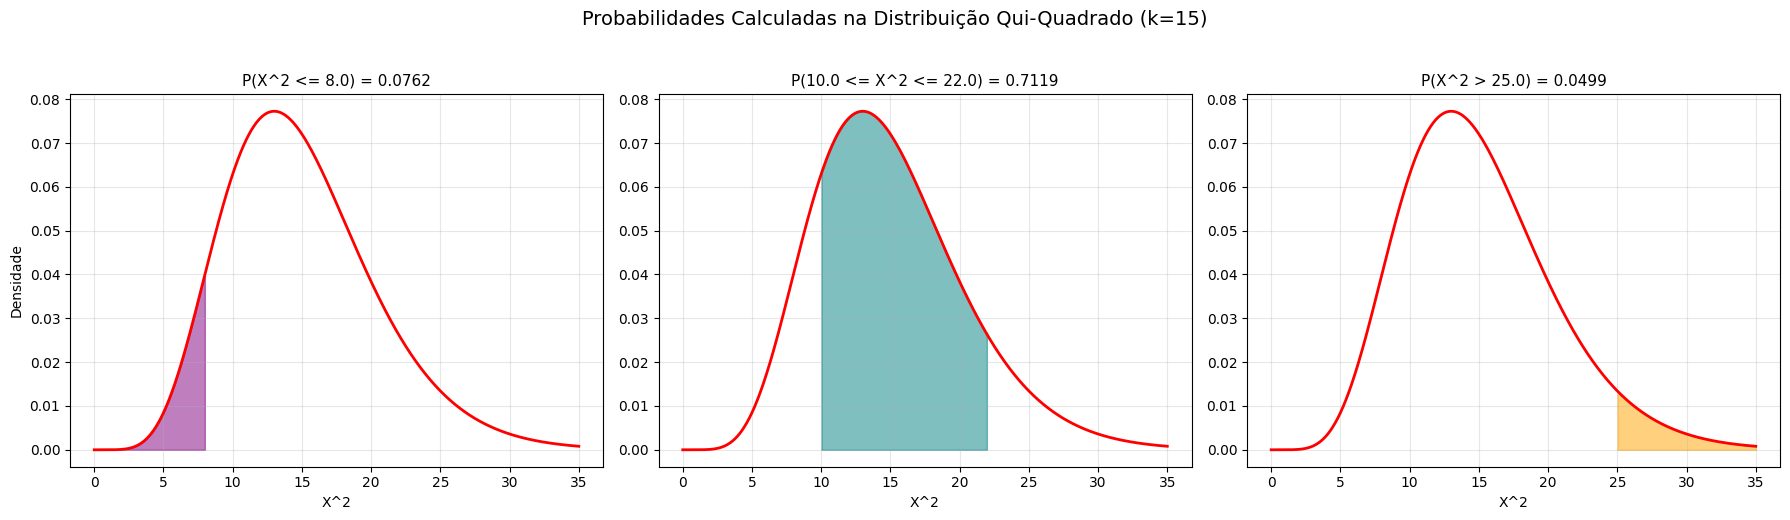

In [23]:
# Gráficos de Densidade com Áreas Sombreadas - Qui-Quadrado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_c = np.linspace(0, 35, 1000)
y_c = stats.chi2.pdf(x_c, df=k_df)

# Gráfico 1: P(X^2 <= 8.0)
axes[0].plot(x_c, y_c, 'r-', lw=2)
axes[0].fill_between(x_c, y_c, where=(x_c <= 8.0), color='purple', alpha=0.5)
axes[0].set_title(f'P(X^2 <= 8.0) = {p_acum_chi:.4f}', fontsize=11)
axes[0].set_xlabel('X^2')
axes[0].set_ylabel('Densidade')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: P(10.0 <= X^2 <= 22.0)
axes[1].plot(x_c, y_c, 'r-', lw=2)
axes[1].fill_between(x_c, y_c, where=((x_c >= 10.0) & (x_c <= 22.0)), color='teal', alpha=0.5)
axes[1].set_title(f'P(10.0 <= X^2 <= 22.0) = {p_entre_chi:.4f}', fontsize=11)
axes[1].set_xlabel('X^2')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: P(X^2 > 25.0)
axes[2].plot(x_c, y_c, 'r-', lw=2)
axes[2].fill_between(x_c, y_c, where=(x_c > 25.0), color='orange', alpha=0.5)
axes[2].set_title(f'P(X^2 > 25.0) = {p_acima_chi:.4f}', fontsize=11)
axes[2].set_xlabel('X^2')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Probabilidades Calculadas na Distribuição Qui-Quadrado (k=15)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

##F de Fisher

F de Fisher é uma distribuição de probabilidade contínua usada na estatística para comparar variâncias (medidas de dispersão de um conjunto de dados).

O valor de F surge da razão (divisão) entre duas variâncias independentes que foram divididas pelos seus respectivos graus de liberdade:
- F próximo de 1: As duas variâncias são muito parecidas, indicando que não há diferença real entre os grupos ou modelos testados;
- F muito maior que 1: A variação explicada pelo seu modelo ou tratamento é bem maior que a variação residual (o erro), o que aponta para uma diferença estatisticamente significativa.


##Identificação dos grupos reais no conjunto de dados
Para efetuar a comparação de variabilidades, definem-se dois grupos reais extraídos da base de dados com base na variável Acidez Fixa (fixed acidity):
- Grupo 1 (Vinho Tinto): n₁= 1599 observações individuais; variância amostral $s_1^2 \approx 3{,}0314$;
- Grupo 2 (Vinho Branco): n₂ = 4898 observações individuais; variância amostral $s_2^2 \approx 0{,}7121$.



##Fórmula de Densidade de Distribuição F de Fisher
A Função Densidade de Probabilidade de uma variável aleatória X com distribuição F de Fisher com $df_1$ e $df_2$ graus de liberdade é dada por:
$$f(x; df_1, df_2) = \frac{\Gamma\left(\frac{df_1 + df_2}{2}\right) \left(\frac{df_1}{df_2}\right)^{\frac{df_1}{2}} x^{\frac{df_1}{2} - 1}}{\Gamma\left(\frac{df_1}{2}\right) \Gamma\left(\frac{df_2}{2}\right) \left(1 + \frac{df_1}{df_2}x\right)^{\frac{df_1 + df_2}{2}}}, \quad \text{para } x > 0$$

Onde:
- x: valor da variável aleatória (x ≥ 0);
- $df_1$: graus de liberdade do numerador (d_1 > 0);
- $df_2$: graus de liberdade do denominador (d_2 > 0);
- Γ: função gama.

##Parâmetros e Compração de Variância

- Graus de liberdade do numerador ($df_1$): Associados à amostra do primeiro grupo ($df_1 = n_1 - 1$). Medem o número de informações independentes utilizadas para estimar a variância no numerador.
- Graus de liberdade do denominador ($df_2$): Associados à amostra do segundo grupo ($df_2 = n_2 - 1$). Medem o número de informações independentes para estimar a variância no denominador.
- Valores admissíveis: A distribuição $F$ assume apenas valores reais estritamente positivos, ou seja, $x \in (0, +\infty)$. Isto deve-se ao facto de ser a razão entre duas somas de quadrados divididas pelos respetivos graus de liberdade.
- Relação com a comparação de variâncias: A estatística de teste é obtida dividindo duas variâncias amostrais independentes: $F = \frac{s_1^2}{s_2^2}$. Sob a hipótese nula de igualdade de variâncias populacionais ($H_0: \sigma_1^2 = \sigma_2^2$), a razão esperada situa-se próxima de 1. Valores significativamente superiores a 1 indicam que a variabilidade do grupo do numerador é superior à do denominador.

##Gráficos variando $df_1$ e $df_2$ de forma separada



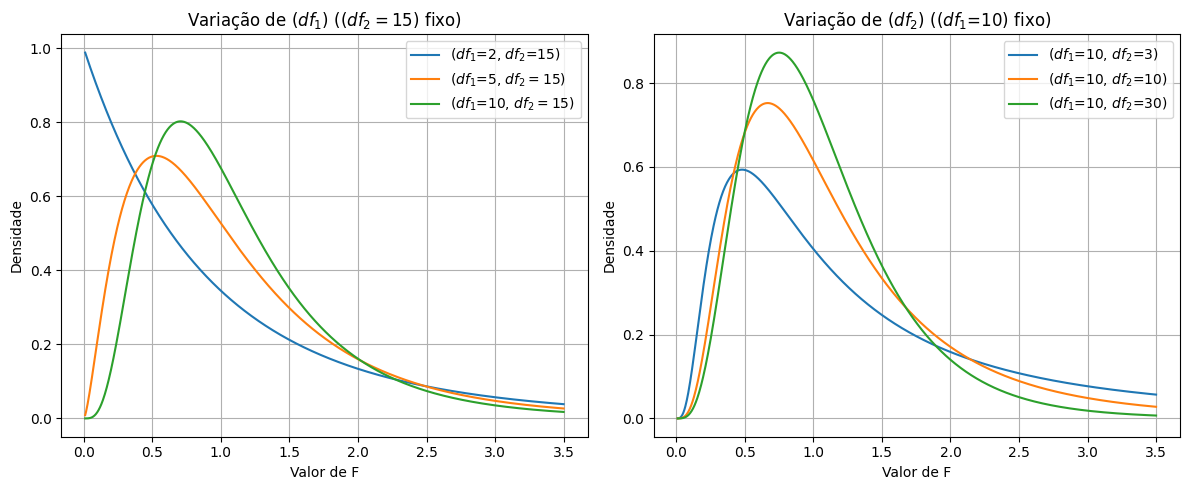

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

x = np.linspace(0.01, 3.5, 1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Variando df1, mantendo df2 = 15 fixo
axes[0].plot(x, f.pdf(x, dfn=2, dfd=15), label=r'($df_1$=2, $df_2$=15)')
axes[0].plot(x, f.pdf(x, dfn=5, dfd=15), label=r'($df_1$=5, $df_2=15$)')
axes[0].plot(x, f.pdf(x, dfn=10, dfd=15), label=r'($df_1$=10, $df_2=15$)')
axes[0].set_title(r'Variação de ($df_1$) (($df_2=15$) fixo)')
axes[0].set_xlabel('Valor de F')
axes[0].set_ylabel('Densidade')
axes[0].legend()
axes[0].grid(True)

# 2. Variando df2, mantendo df1 = 10 fixo
axes[1].plot(x, f.pdf(x, dfn=10, dfd=3), label=r'($df_1$=10, $df_2$=3)')
axes[1].plot(x, f.pdf(x, dfn=10, dfd=10), label=r'($df_1$=10, $df_2$=10)')
axes[1].plot(x, f.pdf(x, dfn=10, dfd=30), label=r'($df_1$=10, $df_2$=30)')
axes[1].set_title(r'Variação de ($df_2$) (($df_1$=10) fixo)')
axes[1].set_xlabel('Valor de F')
axes[1].set_ylabel('Densidade')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##Pergunta Prática Envolvendo as Variâncias dos Grupos
"Existe uma diferença estatisticamente significativa na variabilidade da acidez fixa entre o Vinho Tinto e o Vinho Branco, ao nível de significância de 5%?"

Hipóteses: $H_0: \sigma_{\text{Tinto}}^2 = \sigma_{\text{Branco}}^2$ vs $H_1: \sigma_{\text{Tinto}}^2 > \sigma_{\text{Branco}}^2$;

Razão Amostral: $F_{\text{calculado}} = \frac{s_{\text{Tinto}}^2}{s_{\text{Branco}}^2} = \frac{3{,}0314}{0{,}7121} = 4{,}2569$.

##Cálculos de Probabilidades, Percentil e Gráficos Sombreados

Aviso: Arquivos CSV não encontrados no diretório. Executando modo demonstrativo com valores calculados.

=== CÁLCULOS ESTATÍSTICOS (df1 = 10, df2 = 15) ===
a) P(F <= 1.5): 76.86%
b) P(1.0 <= F <= 2.5): 43.13%
c) P(F > 1.5): 23.14%
d) 95º Percentil Crítico: 2.5437



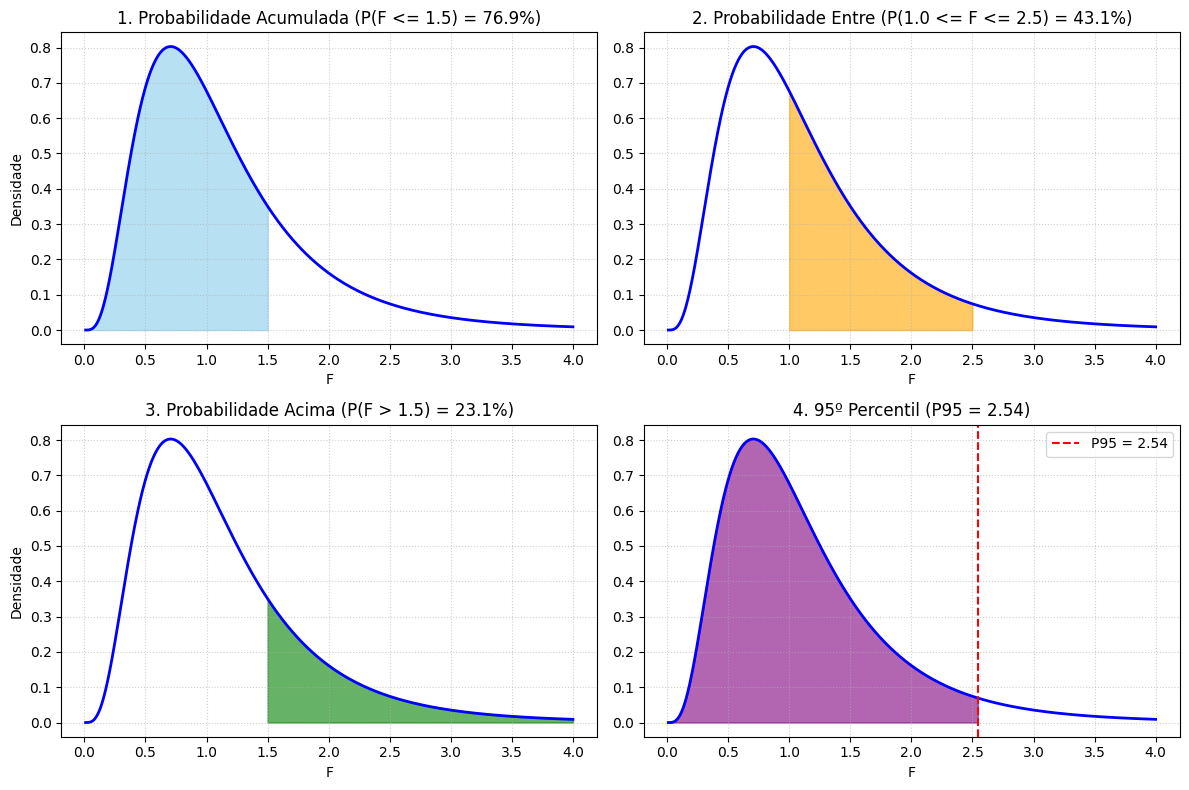

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# -------------------------------------------------------------
# 1. LEITURA DOS DADOS (Com tratamento de erro de caminho)
# -------------------------------------------------------------
red_path = 'winequality-red.csv'
white_path = 'winequality-white.csv'

# Procura os arquivos na pasta atual ou em subpastas
if not os.path.exists(red_path):
    for root, dirs, files in os.walk('.'):
        if 'winequality-red.csv' in files:
            red_path = os.path.join(root, 'winequality-red.csv')
            white_path = os.path.join(root, 'winequality-white.csv')
            break

try:
    df_red = pd.read_csv(red_path, sep=';')
    df_white = pd.read_csv(white_path, sep=';')

    # Cálculo das variâncias reais para a 'fixed acidity'
    var_red = df_red['fixed acidity'].var()
    var_white = df_white['fixed acidity'].var()
    n1, n2 = len(df_red), len(df_white)
    df1_real, df2_real = n1 - 1, n2 - 1
    f_stat_real = var_red / var_white

    print("=== RESULTADOS DO BANCO DE DADOS REAL ===")
    print(f"Variância Vinho Tinto (s1²): {var_red:.4f} (df1 = {df1_real})")
    print(f"Variância Vinho Branco (s2²): {var_white:.4f} (df2 = {df2_real})")
    print(f"F Estatístico Calculado (s1²/s2²): {f_stat_real:.4f}")
    print(f"p-valor para H0 (igualdade): {stats.f.sf(f_stat_real, df1_real, df2_real):.4e}\n")

except FileNotFoundError:
    print("Aviso: Arquivos CSV não encontrados no diretório. Executando modo demonstrativo com valores calculados.\n")
    df1_real, df2_real = 1598, 4897
    f_stat_real = 4.2569

# -------------------------------------------------------------
# 2. CÁLCULOS DAS PROBABILIDADES E PERCENTIL
# Para visualização e compreensão didática da Curva F, usaremos df1 = 10, df2 = 15
# -------------------------------------------------------------
df1_vis, df2_vis = 10, 15

# a) Probabilidade Acumulada: P(F <= 1.5)
p_acumulada = stats.f.cdf(1.5, df1_vis, df2_vis)

# b) Probabilidade Entre Dois Valores: P(1.0 <= F <= 2.5)
p_entre = stats.f.cdf(2.5, df1_vis, df2_vis) - stats.f.cdf(1.0, df1_vis, df2_vis)

# c) Probabilidade Acima de um Valor: P(F > 1.5)
p_acima = stats.f.sf(1.5, df1_vis, df2_vis)

# d) 95º Percentil
percentil_95 = stats.f.ppf(0.95, df1_vis, df2_vis)

print("=== CÁLCULOS ESTATÍSTICOS (df1 = 10, df2 = 15) ===")
print(f"a) P(F <= 1.5): {p_acumulada * 100:.2f}%")
print(f"b) P(1.0 <= F <= 2.5): {p_entre * 100:.2f}%")
print(f"c) P(F > 1.5): {p_acima * 100:.2f}%")
print(f"d) 95º Percentil Crítico: {percentil_95:.4f}\n")

# -------------------------------------------------------------
# 3. GERAÇÃO DOS GRÁFICOS COM ÁREAS SOMBREADAS
# -------------------------------------------------------------
x = np.linspace(0.01, 4.0, 1000)
y = stats.f.pdf(x, df1_vis, df2_vis)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gráfico 1: Probabilidade Acumulada P(F <= 1.5)
axes[0, 0].plot(x, y, 'b', lw=2)
x1 = np.linspace(0.01, 1.5, 500)
axes[0, 0].fill_between(x1, stats.f.pdf(x1, df1_vis, df2_vis), color='skyblue', alpha=0.6)
axes[0, 0].set_title(f'1. Probabilidade Acumulada (P(F <= 1.5) = {p_acumulada*100:.1f}%)')
axes[0, 0].set_xlabel('F')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Probabilidade Entre valores P(1.0 <= F <= 2.5)
axes[0, 1].plot(x, y, 'b', lw=2)
x2 = np.linspace(1.0, 2.5, 500)
axes[0, 1].fill_between(x2, stats.f.pdf(x2, df1_vis, df2_vis), color='orange', alpha=0.6)
axes[0, 1].set_title(f'2. Probabilidade Entre (P(1.0 <= F <= 2.5) = {p_entre*100:.1f}%)')
axes[0, 1].set_xlabel('F')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Gráfico 3: Probabilidade Acima de um valor P(F > 1.5)
axes[1, 0].plot(x, y, 'b', lw=2)
x3 = np.linspace(1.5, 4.0, 500)
axes[1, 0].fill_between(x3, stats.f.pdf(x3, df1_vis, df2_vis), color='green', alpha=0.6)
axes[1, 0].set_title(f'3. Probabilidade Acima (P(F > 1.5) = {p_acima*100:.1f}%)')
axes[1, 0].set_xlabel('F')
axes[1, 0].set_ylabel('Densidade')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 4: 95º Percentil
axes[1, 1].plot(x, y, 'b', lw=2)
x4 = np.linspace(0.01, percentil_95, 500)
axes[1, 1].fill_between(x4, stats.f.pdf(x4, df1_vis, df2_vis), color='purple', alpha=0.6)
axes[1, 1].axvline(percentil_95, color='red', linestyle='--', label=f'P95 = {percentil_95:.2f}')
axes[1, 1].set_title(f'4. 95º Percentil (P95 = {percentil_95:.2f})')
axes[1, 1].set_xlabel('F')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

- Gráfico 1 - Acumulada ($P \le 1{,}5$): Área à esquerda até $1{,}5$ ($76{,}9\%$), indicando a probabilidade de a razão de variâncias ser no máximo $1{,}5$.
- Gráfico 2 - Intervalo ($1{,}0 \le P \le 2{,}5$): Área central ($43{,}1\%$), representando a probabilidade de a razão de variâncias se situar entre $1{,}0$ e $2{,}5$.
- Gráfico 3 - Cauda Direita ($P > 1{,}5$): Área à direita ($23{,}1\%$), medindo a chance de a razão de variâncias ultrapassar $1{,}5$.
- Gráfico 4 - Percentil 95 ($P_{95} = 2{,}54$): Limite crítico de decisão a $5\%$ de significância. Como o valor amostral real dos vinhos ($F \approx 4{,}26$) supera $2{,}54$, conclui-se que as variâncias da acidez nos vinhos tinto e branco são estatisticamente diferentes.

##Conclusão

Em suma, o uso integrado das distribuições Normal, $t$ de Student, Qui-Quadrado e $F$ de Fisher constitui o pilar do rigoroso controle de qualidade na indústria de alimentos e bebidas. Enquanto a Normal e a $t$ de Student certificam que o lote atinja a formulação ideal (como a acidez média estipulada), o Qui-Quadrado e a $F$ de Fisher avaliam a estabilidade dos processos produtivos e comparam a uniformidade entre diferentes linhas de fabricação. Na prática do chão de fábrica, essa análise estatística permite detectar precocemente oscilações nas matérias-primas, otimizar tolerâncias de envasamento e garantir que o alimento chegue ao consumidor com máxima segurança, estabilidade e padronização.

##Referências

https://archive.ics.uci.edu/dataset/186/wine+quality

https://www.inf.ufsc.br/~andre.zibetti/probabilidade/normal.html

BUSSAB, Wilton de O.; MORETTIN, Pedro A. Estatística Básica. 9. ed. São Paulo: Saraiva, 2017.

CORTEZ, Paulo; CERDEIRA, António; ALMEIDA, Fernando; MATOS, Telmo; REIS, José. Wine Quality. UCI Machine Learning Repository, 2009.

MONTGOMERY, Douglas C.; RUNGER, George C. Estatística Aplicada e Probabilidade para Engenheiros. 7. ed. Rio de Janeiro: LTC, 2018.